# Literaturvergleich – Day-Ahead PV-Forecasting

Dieses Notebook erstellt ein publikationsreifes Balkendiagramm, das unsere Random-Forest-Ergebnisse in den Kontext der Literatur einordnet.

**Referenz:** Theocharides et al. (2021), *Day-Ahead Photovoltaic Power Production Forecasting Methodology Based on Machine Learning and Statistical Post-Processing*, Energies 14, 1081.

In [1]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

RESULTS_PATH = Path('../../results/02_random_forest/random_forest_base_with_time_and_lag.json')
OUT_DIR      = Path('../../results/figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

with open(RESULTS_PATH) as f:
    rf_result = json.load(f)

P_NOM = 8_500.0

our_nrmse_val  = rf_result['splits']['val']['rmse']  / P_NOM * 100
our_nrmse_test = rf_result['splits']['test']['rmse'] / P_NOM * 100
our_mape_val   = rf_result['splits']['val']['mape_daytime']
our_mape_test  = rf_result['splits']['test']['mape_daytime']

# Rohwerte einmalig ausgeben für verschiedene Normalisierungen
rmse_val  = rf_result['splits']['val']['rmse']
rmse_test = rf_result['splits']['test']['rmse']
print(f"RMSE absolut – Val: {rmse_val:.1f} W  |  Test: {rmse_test:.1f} W")
print()
for p in [13_500, 11_700, 10_000, 8_500]:
    print(f"P_nom={p:>6} W  →  nRMSE Val: {rmse_val/p*100:.2f}%  |  nRMSE Test: {rmse_test/p*100:.2f}%")
print()
print(f"Aktiv (P_nom={P_NOM:.0f} W): nRMSE Val={our_nrmse_val:.2f}%  MAPE Val={our_mape_val:.2f}%")
print(f"Aktiv (P_nom={P_NOM:.0f} W): nRMSE Test={our_nrmse_test:.2f}%  MAPE Test={our_mape_test:.2f}%")

RMSE absolut – Val: 395.6 W  |  Test: 366.2 W

P_nom= 13500 W  →  nRMSE Val: 2.93%  |  nRMSE Test: 2.71%
P_nom= 11700 W  →  nRMSE Val: 3.38%  |  nRMSE Test: 3.13%
P_nom= 10000 W  →  nRMSE Val: 3.96%  |  nRMSE Test: 3.66%
P_nom=  8500 W  →  nRMSE Val: 4.65%  |  nRMSE Test: 4.31%

Aktiv (P_nom=8500 W): nRMSE Val=4.65%  MAPE Val=1.63%
Aktiv (P_nom=8500 W): nRMSE Test=4.31%  MAPE Test=1.79%


In [2]:
# ── Literaturdaten ─────────────────────────────────────────────────────────
# Theocharides et al. (2021), Energies 14, 1081
# Normalisierung: nRMSE auf P_nominal; MAPE klassisch

models = [
    # label                          nRMSE   MAPE    group
    ('BNN (mit Filter)',              4.53,   3.17,  'Theocharides'),
    ('SVR (mit Filter)',              6.37,   5.83,  'Theocharides'),
    ('RT (mit Filter)',               7.37,   6.27,  'Theocharides'),
    ('BNN (ohne Filter)',             6.51,   5.39,  'Theocharides'),
    ('SVR (ohne Filter)',             7.74,   6.61,  'Theocharides'),
    ('RT (ohne Filter)',              8.43,   6.98,  'Theocharides'),
    (f'RF TIME+LAG – Val\n(diese Arbeit)',  our_nrmse_val,  our_mape_val,  'Diese Arbeit'),
    (f'RF TIME+LAG – Test\n(diese Arbeit)', our_nrmse_test, our_mape_test, 'Diese Arbeit'),
]

nrmse_models = [(l, v, g) for l, v, m, g in models]
mape_models  = [(l, m, g) for l, v, m, g in models]

# Bereiche für Diagramm 2
th_nrmse_vals = [v for _, v, _, g in models if g == 'Theocharides']
th_mape_vals  = [m for _, _, m, g in models if g == 'Theocharides']

GROUP_COLORS = {
    'Theocharides': '#7BA7BC',
    'Diese Arbeit': '#E07B39',
}
GROUP_EDGE = {
    'Theocharides': '#4A7A96',
    'Diese Arbeit': '#A84F10',
}

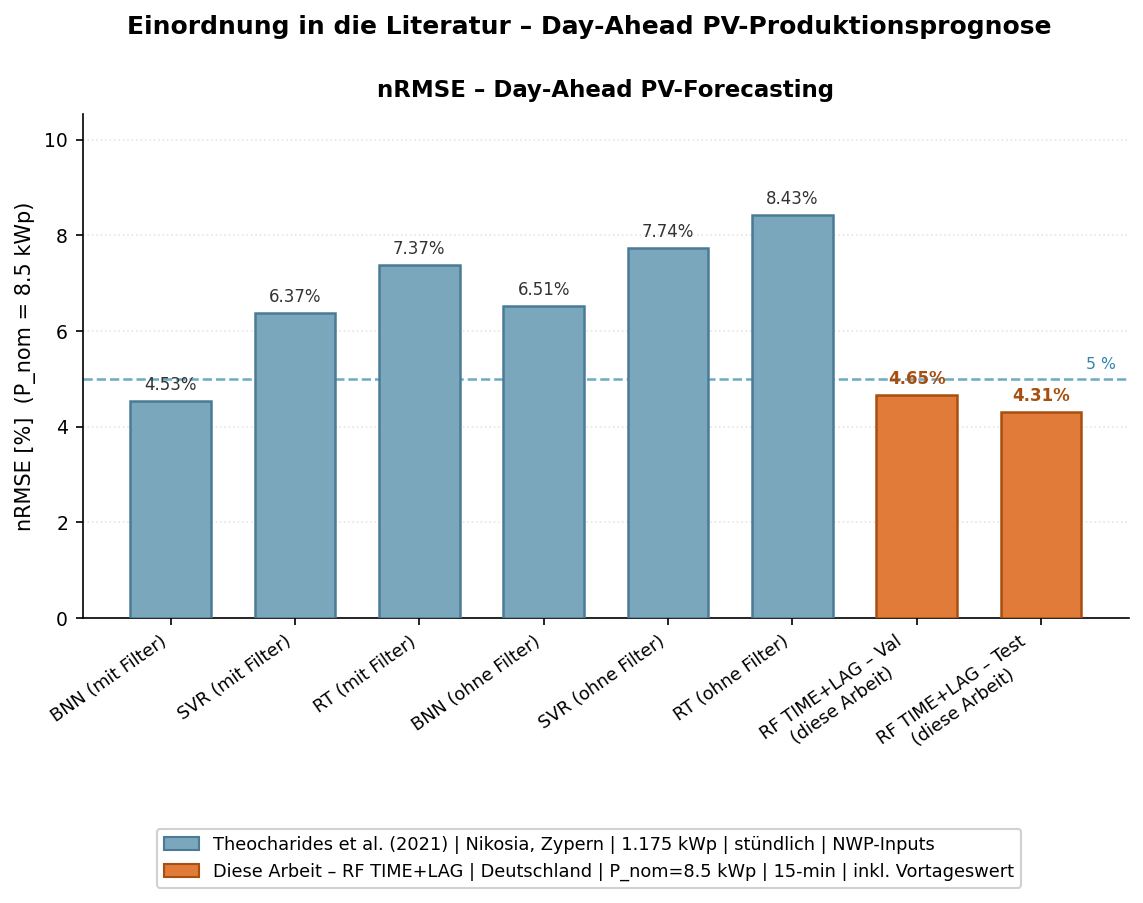

In [3]:
# ── Diagramm 1: Alle Theocharides-Modelle einzeln ───────────────────────────
matplotlib.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  8.5,
    'ytick.labelsize':  9,
    'figure.dpi':       150,
})

def draw_bar_panel(ax, data, ylabel, ref_lines, title):
    labels = [d[0] for d in data]
    values = [d[1] for d in data]
    groups = [d[2] for d in data]
    colors = [GROUP_COLORS[g] for g in groups]
    edges  = [GROUP_EDGE[g]   for g in groups]

    x = np.arange(len(labels))
    bars = ax.bar(x, values, color=colors, edgecolor=edges,
                  linewidth=1.2, width=0.65, zorder=3)

    for bar, val, grp in zip(bars, values, groups):
        weight = 'bold' if grp == 'Diese Arbeit' else 'normal'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.15,
                f'{val:.2f}%', ha='center', va='bottom',
                fontsize=8, fontweight=weight,
                color='#A84F10' if grp == 'Diese Arbeit' else '#333333')

    for ref_val, ref_label, ref_color in ref_lines:
        ax.axhline(ref_val, color=ref_color, linewidth=1.2,
                   linestyle='--', alpha=0.7, zorder=2)
        ax.text(len(labels) - 0.4, ref_val + 0.15, ref_label,
                fontsize=7.5, color=ref_color, va='bottom', ha='right')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right', multialignment='center')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_ylim(0, max(values) * 1.25)
    ax.set_facecolor('white')
    ax.grid(axis='y', linestyle=':', alpha=0.5, color='#cccccc', zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

fig, ax = plt.subplots(figsize=(9, 6), facecolor='white')
fig.subplots_adjust(bottom=0.32)

draw_bar_panel(
    ax, nrmse_models,
    ylabel=f'nRMSE [%]  (P_nom = {P_NOM/1000:.1f} kWp)',
    ref_lines=[(5, '5 %', '#2E86AB')],
    title='nRMSE – Day-Ahead PV-Forecasting'
)

legend_handles = [
    mpatches.Patch(facecolor=GROUP_COLORS['Theocharides'], edgecolor=GROUP_EDGE['Theocharides'],
                   label='Theocharides et al. (2021) | Nikosia, Zypern | 1.175 kWp | stündlich | NWP-Inputs'),
    mpatches.Patch(facecolor=GROUP_COLORS['Diese Arbeit'], edgecolor=GROUP_EDGE['Diese Arbeit'],
                   label=f'Diese Arbeit – RF TIME+LAG | Deutschland | P_nom={P_NOM/1000:.1f} kWp | 15-min | inkl. Vortageswert'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=1,
           fontsize=8.5, framealpha=0.9, bbox_to_anchor=(0.5, 0.01),
           edgecolor='#cccccc')

fig.suptitle('Einordnung in die Literatur – Day-Ahead PV-Produktionsprognose',
             fontsize=12, fontweight='bold', y=0.99)

plt.show()

## Hinweise zur Vergleichbarkeit

| Aspekt | Diese Arbeit | Theocharides et al. (2021) |
|--------|-------------|----------------------------|
| Standort | Deutschland (gemäßigt, weniger Strahlung) | Nikosia, Zypern (Mittelmeer, viel Sonne) |
| Systemgröße | 13.700 kWp | 1.175 kWp |
| Zeitauflösung | **15 min** | stündlich |
| MAPE-Berechnung | alle Tagzeit-Slots (Prod. > 0) | nur Slots mit Einstrahlung ≥ 600 W/m² |
| Modell-Inputs | Wetter + Zeitfeatures + **Vortageswert (Lag)** | NWP-Forecasts (kein Lag) |
| nRMSE-Basis | P_nom = 8.500 kWp (verringert, weil 50% der Module Nordseite) | 1.175 kWp |

**Warum kein fairer Vergleich möglich ist:**

- **Standort:** Deutschland hat deutlich weniger Globalstrahlung als Zypern. Geringere Spitzenwerte bedeuten niedrigere absolute Fehler bei gleicher relativer Güte.
- **Lag-Feature:** Unser bestes Modell nutzt den Produktionswert des gleichen 15-min-Slots vom Vortag — ein starkes Signal bei stabilen Wetterlagen, das die Literaturmodelle nicht verwenden.
- **MAPE-Filter:** Theocharides werten z.T. nur High-Irradiance-Slots (≥ 600 W/m²) aus, was Morgendämmerung und bewölkte Stunden ausschließt — typisch schwierige Zeitschritte fehlen damit.
- **Auflösung:** 15-min-Prognosen sind schwieriger als stündliche, da kurzfristige Variabilität stärker ins Gewicht fällt.

**Fazit:** Die Abbildung zeigt, dass unsere Ergebnisse **in der Größenordnung** der Literatur liegen. Ein direkter Qualitätsvergleich ist aufgrund der unterschiedlichen Randbedingungen nicht zulässig.